# Preamble

## Imports

In [1]:
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import LocallyIsothermalEOS  
from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code, GasConst, Omega0, AU, Msun  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf

## Useful Functions

In [2]:
def Sigma_LBP_1(r,Mdisk,Rc) -> float:
    val = (Mdisk)/(2* np.pi * Rc * r) * np.exp((-1*r)/(Rc))
    if (val.cgs.unit != (u.g / (u.cm)**2)):
        print("Sigma_1 error")
        return 0
    return val.cgs

In [3]:
import os

_NOTEBOOK_DIR = os.path.dirname(os.path.abspath("ConstantAlphaTesting.ipynb"))
_OUTPUT_DIR = os.path.join(_NOTEBOOK_DIR, 'output')

def savefig(filename, subfolder=None, dpi=250, **kwargs):
    """Save the current figure under <notebook_dir>/output/[subfolder]/filename."""
    base = os.path.join(_OUTPUT_DIR, subfolder) if subfolder else _OUTPUT_DIR
    path = os.path.join(base, filename)
    os.makedirs(base, exist_ok=True)
    plt.savefig(path, dpi=dpi, **kwargs)
    print(f"Saved: {path}")

In [4]:
#old, might need updates
def compute_alpha_turb_array(R, H, R_dz, alpha_dead, alpha_active, width_factor=1.0):
    """
    Creates a smooth alpha_turb array that transitions at R_dz.
    Transitions in log-space to ensure smooth orders of magnitude.
    
    Args:
        R: radial grid (array, AU)
        H: scale height (array, AU)
        R_dz: dead zone radius (scalar, AU)
        alpha_dead: turbulent alpha in dead zone
        alpha_active: turbulent alpha in active zone
        width_factor: transition width in units of H at R_dz
    """

    log_a_dead = np.log10(alpha_dead)
    log_a_active = np.log10(alpha_active)

    # Find the exact scale height (H) at the deadzone boundary
    H_at_rdz = np.interp(R_dz, R, H)
    
    # Tanh transition: 0 in dead zone, 1 in active zone
    transition = 0.5 * (1.0 + np.tanh((R - R_dz) / (width_factor * H_at_rdz)))
    
    # Blend in log space
    log_alpha_array = log_a_dead + transition * (log_a_active - log_a_dead)
    
    return 10**log_alpha_array

In [5]:
#old, might need updates
def compute_R_dz(t_yr, R_dz_initial_AU, R_dz_min_AU, t_start_yr, t_final_yr) -> float: 
    """
    Moves Rdz linearly from initial to min over the disc lifetime.
    """

    disc_lifetime_yr = t_final_yr - t_start_yr
    distance = R_dz_initial_AU.value - R_dz_min_AU.value 
    velocity = distance / disc_lifetime_yr #Au/yr 
    t_rel = max(0.0, t_yr - t_start_yr)

    return max(R_dz_initial_AU.value - (velocity * t_rel), R_dz_min_AU.value) 

# 0. Simulation Parameters

In [6]:
t_initial = 0.0 * u.Myr
t_initial_yr = t_initial.to(u.yr).value 
t_initial_code = t_initial_yr * yr_code  #Convert to code units

t_final = 1.0 * u.Myr
t_final_yr = t_final.to(u.yr).value 
t_final_code = t_final_yr * yr_code  #Convert to code units

M_disk_0 = 0.28 * u.solMass 
Rc = 91.0 * u.AU #where disc starts fading out at 0.1 Myr in order to be at 120 AU at 1Myr
Mstar = 1.2 * u.solMass
Rstar = 3.0 * u.solRad
Tstar = 4395.0 * u.K
mu = 2.33

#Reference Values
Mdot_ref = 1.6e-7
alpha_SS_DZ = 1e-5

subfolder = 'VaryingAlphaTesting'

# 1. Grid

In [7]:
R_in = 0.1   # AU
R_out = 400.0  # AU — must be >> Rc (91 AU) so the spreading front never reaches the boundary
Ncells = 500
grid = Grid(R_in, R_out, Ncells, spacing='natural')
R_centers = grid.Rc  # AU

# 2. Star

In [8]:
star = SimpleStar(M = Mstar.value ,      #Msun
                  R = Rstar.value,       #Rsun
                  T_eff = Tstar.value,   #K
                  age = t_initial_yr)    #yr

# 2.2 Initial Alpha Profiles

## Get Psi from Mdot & alpha_SS (deadzone)

Analytical solution (won't use, instead recursively solve for it)
\begin{equation*}
\dot{M} = \frac{3 \pi \Sigma_0}{\Omega_K} \alpha_{SS} \bigg[ A(r_{in}) + B(r_{in})\psi \bigg]
\end{equation*}

\begin{equation*}
\dot{M} = \frac{3 \pi \Sigma_0}{\Omega_K} \alpha_{SS} \bigg[ \frac{2}{u} \frac{\partial}{\partial u}(ue^{-u}c_s^2) + u^{-1}e^{-u}c_s^2\psi \bigg]
\end{equation*}
where $u = r/r_c$

Derivation for the convergence method:

When inside the deadzone, Psi >> 1
\begin{equation*}
    \dot{M} \propto \alpha_{SS} (1 + b\psi)
\end{equation*}

\begin{equation*}
    \dot{M} \propto \alpha_{SS} (\psi)
\end{equation*}

\begin{equation*}
    \frac{\dot{M}}{\dot{M_{ref}}} \propto \frac{\alpha_{SS} (\psi)}{\alpha_{SS} (\psi_{ref})}
\end{equation*}

\begin{equation*}
    \psi_{ref} = \psi \frac{\dot{M_{ref}}}{\dot{M}}
\end{equation*}

## Set reference and guess values

algorithm taken from run_model_combined_29_Jul.py

In [9]:
#N.B. Reference values set in section 0

#Initial Guess for Psi (what we are numerically converging to)
psi_guess = 0.01

## Create intial disc, wind, eos for first guess

In [10]:
#Create placeholder objects
#eos 
eos_temp = IrradiatedEOS(
   star,
    alpha_t=alpha_SS_DZ,   
    Tc=10,                  #External/nebular temperature floor (K)
    Tmax=1500,              #max temperature cap (K)
    mu=mu,
    gamma=1.0,
    accrete=True,           #Include viscous heating from accretion
    kappa=Zhu2012,
    e_rad= 0.9 #0.99 Maybe given new data
)
eos_temp.set_grid(grid)

Sigma_temp = np.array([Sigma_LBP_1(r * u.AU, M_disk_0, Rc).value for r in R_centers])
eos_temp.update(0, Sigma_temp)

#Disc 
disc_temp = DustGrowthTwoPop(
    grid, 
    star, 
    eos_temp, 
    eps=0.01,              #Initial dust-to-gas ratio
    Sigma=Sigma_temp,
    feedback=True,         #Dust affects gas dynamics
    f_ice=1,               #Ice fraction (affects fragmentation)
    uf_0=100,              #Fragmentation velocity for dry grains (cm/s)
    uf_ice=1000,           #Fragmentation velocity for icy grains (cm/s)
    thresh=0.5             #Threshold for ice effects
)
disc_temp._planetesimal = False #Turn off planetessimals for now
disc_temp.update(0.0)           #This is to have the pebble size and stokes number correct at t=0

#Wind 
wind_temp = HybridWindModel(psi_DW=psi_guess, 
                            lambda_DW=3.0, 
                            tol=0.5, 
                            boundary='power_law', 
                            in_bound='Mdot')
disc_temp._gas = wind_temp #Attach to _gas object

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/eos.py:467: RuntimeWarning: divide by zero encountered in divide
  return 1. / Pr_1


## Compute Initial Mdot values from the first psi guess, Scale sigma for good total disc mass

In [11]:
#Use temp objects to compute initial Mdot given psi guess
Mdot_iteration = disc_temp.Mdot(wind_temp.viscous_velocity(disc_temp)[0])

#from run_model_combined_29_Jul.py
#scale Sigma by current Mtot just in case Sigma is not quite at the correct value to have the desired Mdisk (which often happens)
Mtot_scaling = disc_temp.Mtot() * u.g.to(u.solMass)
Sigma_temp[:] *= M_disk_0.value / Mtot_scaling

In [12]:
psi_guess, Mdot_iteration

(0.01, np.float64(1.1151302077063218e-09))

## Iterate until convergence to a psi that gives the reference Mdot

In [13]:
for i in tqdm(range(15)):
    # Create the EOS
    eos_temp = IrradiatedEOS(
    star,
    alpha_t=alpha_SS_DZ,   
    Tc=10,                  #External/nebular temperature floor (K)
    Tmax=1500,              #max temperature cap (K)
    mu=mu,
    gamma=1.0,
    accrete=True,           #Include viscous heating from accretion
    kappa=Zhu2012,
    e_rad= 0.9 #0.99 Maybe given new data
    )
    
    # update eos with grid and Sigma
    eos_temp.set_grid(grid)
    Sigma_temp = np.array([Sigma_LBP_1(r * u.AU, M_disk_0, Rc).value for r in R_centers])
    eos_temp.update(0, Sigma_temp)

    # define new disc 
    disc_temp = DustGrowthTwoPop(
    grid, 
    star, 
    eos_temp, 
    eps=0.01,              #Initial dust-to-gas ratio
    Sigma=Sigma_temp,
    feedback=True,         #Dust affects gas dynamics
    f_ice=1,               #Ice fraction (affects fragmentation)
    uf_0=100,              #Fragmentation velocity for dry grains (cm/s)
    uf_ice=1000,           #Fragmentation velocity for icy grains (cm/s)
    thresh=0.5             #Threshold for ice effects
    )
    disc_temp._planetesimal = False #Turn off planetessimals for now
    disc_temp.update(0.0)           #This is to have the pebble size and stokes number correct at t=0

    wind_temp = HybridWindModel(psi_DW=psi_guess, 
                            lambda_DW=3.0, 
                            tol=0.5, 
                            boundary='power_law', 
                            in_bound='Mdot')
    disc_temp._gas = wind_temp #Attach to _gas object

    # find current Mdot in the disc given Sigma and current eos
    Mdot_iteration = disc_temp.Mdot(wind_temp.viscous_velocity(disc_temp)[0])

    # Scale psi by Mdot
    psi_new = psi_guess*Mdot_ref/Mdot_iteration
    psi_guess = 0.5 * (psi_guess + psi_new) # average done to damp oscillations in numerical solution

    # find a new psi_guess given new psi.
    psi_guess = psi_guess * (Mdot_ref/Mdot_iteration)

    print(psi_guess, Mdot_iteration)

  0%|          | 0/15 [00:00<?, ?it/s]

103.65139524992652 1.1151302077063218e-09
575.8662273620677 5.573559893970179e-08
230.69175963932213 3.045994376594336e-07
346.5989113359276 1.2268765254819673e-07
282.246000743434 1.8377234693881556e-07
311.5465908633201 1.4985746059100087e-07
296.7250138422778 1.6529928248671092e-07
303.8617927845501 1.574881035433507e-07
300.3396379007602 1.6124928612993713e-07
302.0572708109036 1.5939306111255507e-07
301.2147064427075 1.602982777437602e-07
301.62683243044904 1.5985423450585538e-07
301.4249643790321 1.600714306809242e-07
301.52377562392553 1.5996504338689155e-07
301.475392769288 1.6001711829864907e-07


In [18]:
psi_DZ = psi_guess
print(psi_DZ)

301.475392769288


# 2.3 Build deadzone, alpha_SS(R), alpha_DW(R), psi(R)

compute inside DZ

In [66]:
#Have: psi_DZ, alpha_SS , alpha_SS_AZ
#Need: alpha_DW_DZ , psi_AZ
alpha_DW_DZ = psi_DZ * alpha_SS_DZ
alpha_eff = alpha_SS_DZ + alpha_DW_DZ

print(psi_DZ, alpha_SS_DZ, alpha_DW_DZ, alpha_eff)

301.475392769288 1e-05 0.0030147539276928806 0.0030247539276928807


compute active zone

In [67]:
psi_AZ = 1. / psi_DZ
alpha_SS_AZ = alpha_eff / (1 + psi_AZ)     
alpha_DW_AZ = psi_AZ * alpha_SS_AZ

print(psi_AZ, alpha_SS_AZ, alpha_DW_AZ, alpha_eff)

0.003317020307409555 0.0030147539276928806 1e-05 0.0030247539276928807


Alpha_SS array (both DZ and AZ)

In [68]:
Rgrid = grid.Rc
scaleHeight = eos_temp.H #from old convergence eos but just to get a reasonable scale height 

alpha_SS_arr = compute_alpha_turb_array(R=Rgrid, 
                        H=scaleHeight, 
                        R_dz=20, 
                        alpha_dead=alpha_SS_DZ,
                        alpha_active= alpha_SS_AZ,
                        width_factor=2
                        )

In [69]:
alpha_SS_arr

array([1.00000000e-05, 1.00000000e-05, 1.00000000e-05, 1.00000000e-05,
       1.00000001e-05, 1.00000001e-05, 1.00000001e-05, 1.00000001e-05,
       1.00000001e-05, 1.00000001e-05, 1.00000001e-05, 1.00000001e-05,
       1.00000001e-05, 1.00000001e-05, 1.00000001e-05, 1.00000001e-05,
       1.00000001e-05, 1.00000001e-05, 1.00000001e-05, 1.00000001e-05,
       1.00000002e-05, 1.00000002e-05, 1.00000002e-05, 1.00000002e-05,
       1.00000002e-05, 1.00000003e-05, 1.00000003e-05, 1.00000003e-05,
       1.00000004e-05, 1.00000004e-05, 1.00000005e-05, 1.00000005e-05,
       1.00000006e-05, 1.00000007e-05, 1.00000008e-05, 1.00000009e-05,
       1.00000010e-05, 1.00000012e-05, 1.00000014e-05, 1.00000016e-05,
       1.00000019e-05, 1.00000022e-05, 1.00000026e-05, 1.00000031e-05,
       1.00000036e-05, 1.00000043e-05, 1.00000051e-05, 1.00000062e-05,
       1.00000074e-05, 1.00000089e-05, 1.00000108e-05, 1.00000131e-05,
       1.00000159e-05, 1.00000194e-05, 1.00000238e-05, 1.00000292e-05,
      

Psi array

In [70]:
psi_arr = (alpha_eff / alpha_SS_arr) - 1

In [71]:
psi_arr

array([3.01475391e+02, 3.01475391e+02, 3.01475391e+02, 3.01475391e+02,
       3.01475391e+02, 3.01475391e+02, 3.01475391e+02, 3.01475391e+02,
       3.01475391e+02, 3.01475391e+02, 3.01475391e+02, 3.01475391e+02,
       3.01475390e+02, 3.01475390e+02, 3.01475390e+02, 3.01475390e+02,
       3.01475390e+02, 3.01475389e+02, 3.01475389e+02, 3.01475389e+02,
       3.01475388e+02, 3.01475388e+02, 3.01475387e+02, 3.01475387e+02,
       3.01475386e+02, 3.01475385e+02, 3.01475384e+02, 3.01475383e+02,
       3.01475382e+02, 3.01475381e+02, 3.01475379e+02, 3.01475377e+02,
       3.01475375e+02, 3.01475373e+02, 3.01475370e+02, 3.01475366e+02,
       3.01475362e+02, 3.01475357e+02, 3.01475351e+02, 3.01475344e+02,
       3.01475336e+02, 3.01475326e+02, 3.01475314e+02, 3.01475300e+02,
       3.01475283e+02, 3.01475262e+02, 3.01475237e+02, 3.01475206e+02,
       3.01475169e+02, 3.01475123e+02, 3.01475067e+02, 3.01474998e+02,
       3.01474912e+02, 3.01474806e+02, 3.01474674e+02, 3.01474510e+02,
      

alpha_Dw

In [72]:
alpha_DW_arr = psi_arr * alpha_SS_arr

In [73]:
alpha_DW_arr

array([3.01475393e-03, 3.01475393e-03, 3.01475393e-03, 3.01475393e-03,
       3.01475393e-03, 3.01475393e-03, 3.01475393e-03, 3.01475393e-03,
       3.01475393e-03, 3.01475393e-03, 3.01475393e-03, 3.01475393e-03,
       3.01475393e-03, 3.01475393e-03, 3.01475393e-03, 3.01475393e-03,
       3.01475393e-03, 3.01475393e-03, 3.01475393e-03, 3.01475393e-03,
       3.01475393e-03, 3.01475393e-03, 3.01475393e-03, 3.01475393e-03,
       3.01475393e-03, 3.01475393e-03, 3.01475393e-03, 3.01475393e-03,
       3.01475393e-03, 3.01475393e-03, 3.01475393e-03, 3.01475393e-03,
       3.01475393e-03, 3.01475393e-03, 3.01475393e-03, 3.01475393e-03,
       3.01475393e-03, 3.01475393e-03, 3.01475393e-03, 3.01475393e-03,
       3.01475393e-03, 3.01475393e-03, 3.01475393e-03, 3.01475392e-03,
       3.01475392e-03, 3.01475392e-03, 3.01475392e-03, 3.01475392e-03,
       3.01475392e-03, 3.01475392e-03, 3.01475392e-03, 3.01475391e-03,
       3.01475391e-03, 3.01475391e-03, 3.01475390e-03, 3.01475390e-03,
      

alpha_eff

In [74]:
alpha_eff_arr = alpha_SS_arr * (1 + psi_arr)

In [75]:
alpha_eff_arr

array([0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302475,
       0.00302475, 0.00302475, 0.00302475, 0.00302475, 0.00302

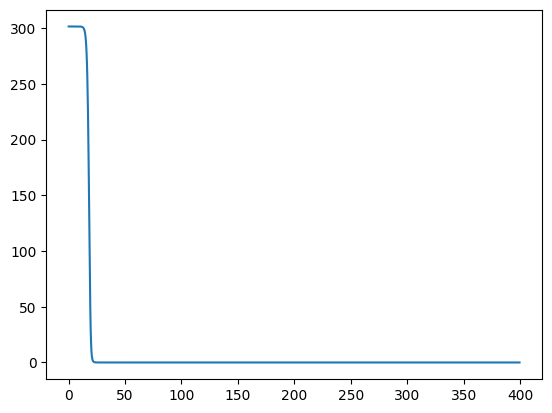

In [76]:
plt.plot(Rgrid, psi_arr)

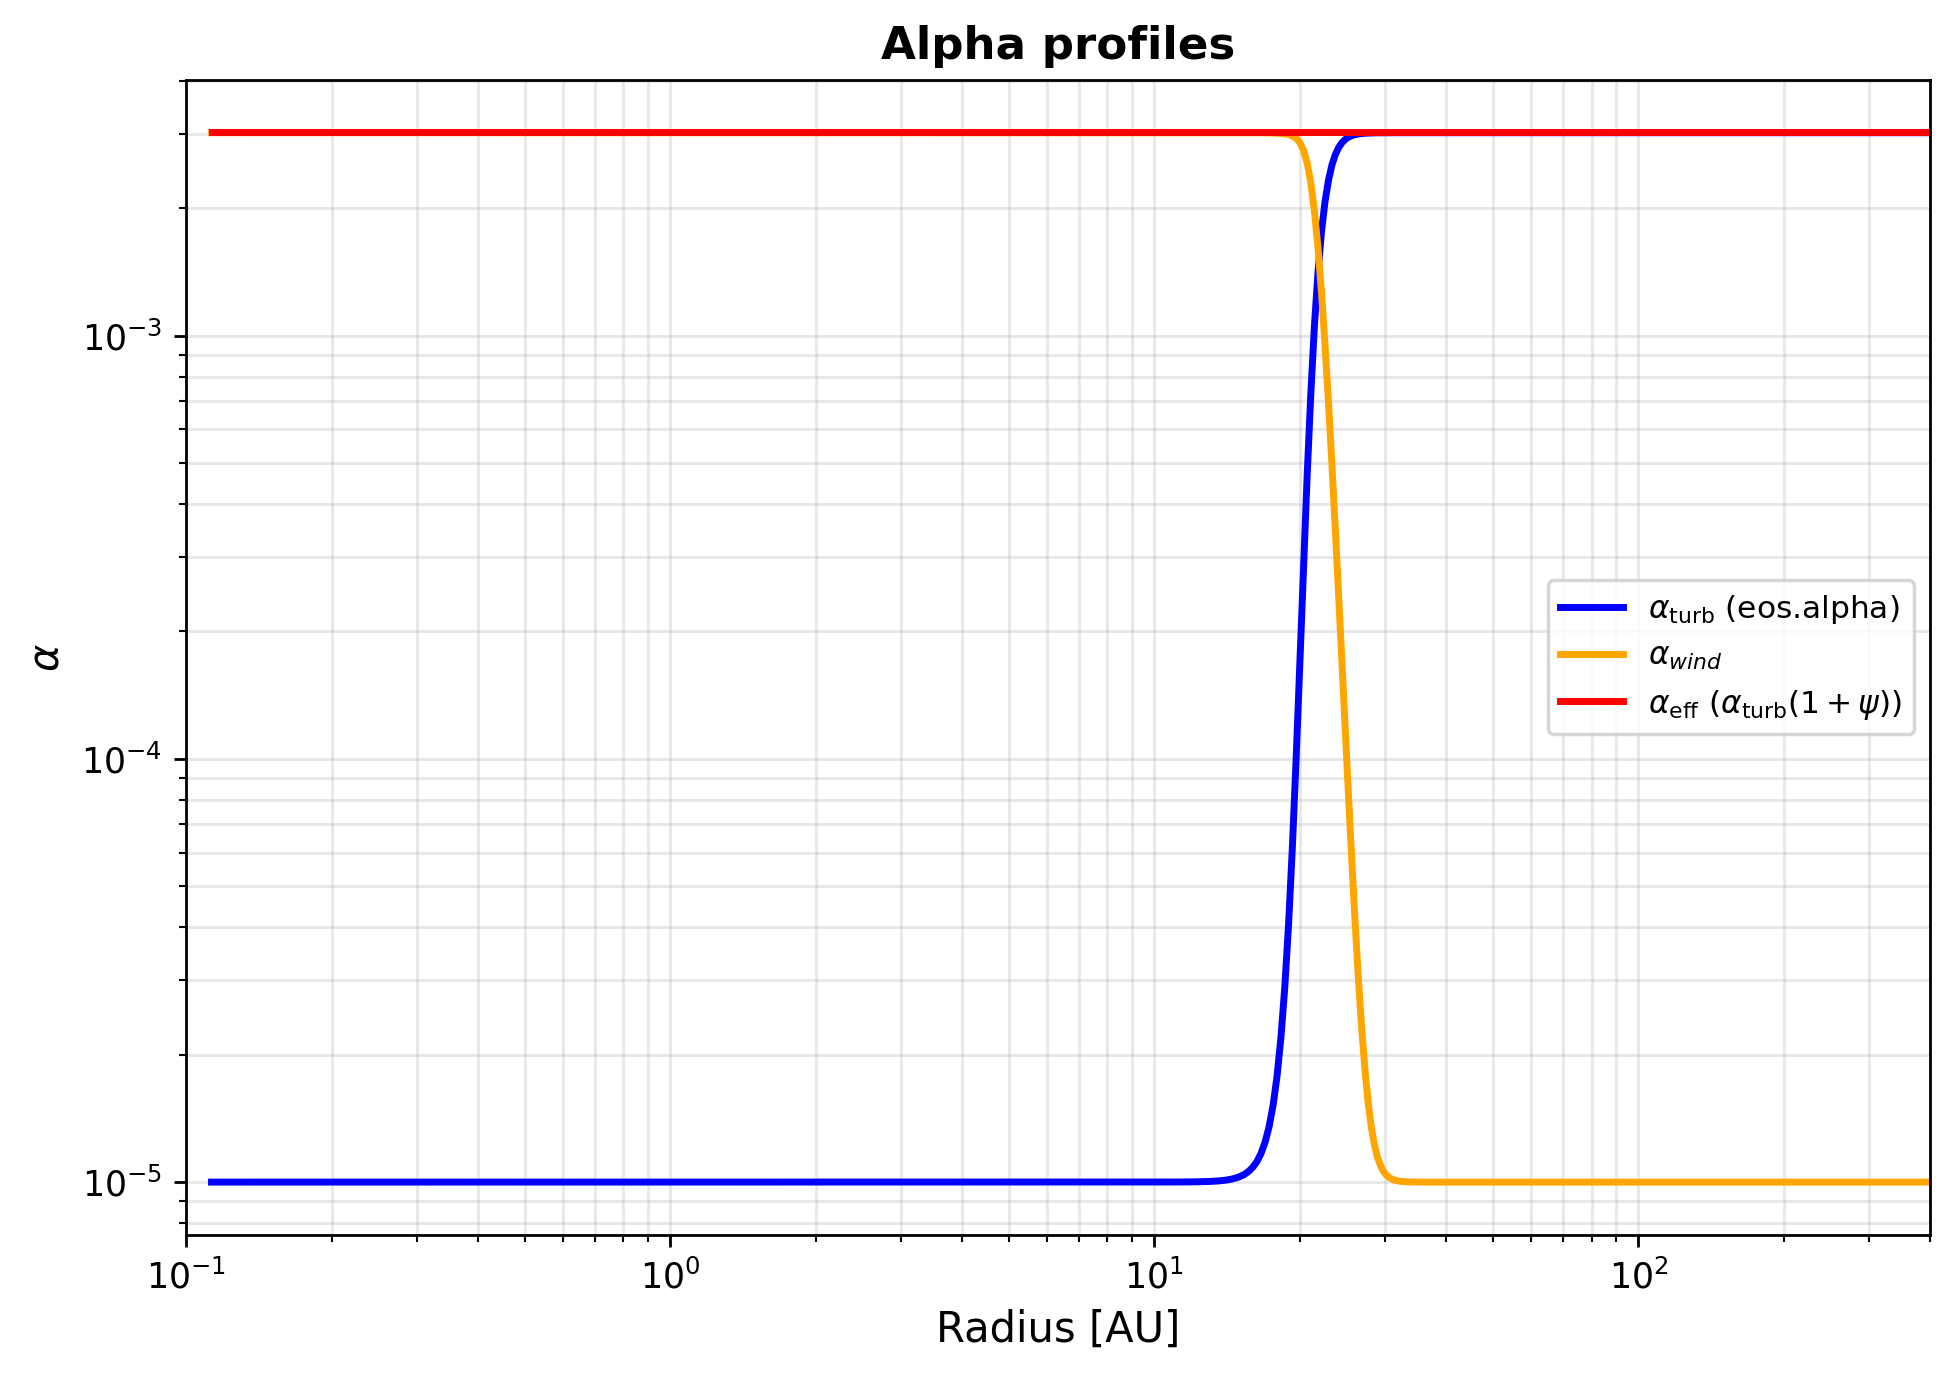

In [77]:
fig, ax = plt.subplots(figsize=(9, 6), dpi = 250)

ax.loglog(Rgrid, alpha_SS_arr, label=r'$\alpha_{\rm turb}$ (eos.alpha)', lw=2, color='blue')
ax.loglog(Rgrid, alpha_DW_arr, label=r'$\alpha_{wind}$', lw=2, color='orange')
ax.loglog(Rgrid, alpha_eff_arr, label=r'$\alpha_{\rm eff}$ ($\alpha_{\rm turb}(1+\psi)$)', lw=2, color='red')
#ax.loglog(Rgrid, alpha_from_nu, label=r'$\nu / (c_s H)$ (back-calculated)', lw=1, ls='--', color='lime')

ax.set_xlabel('Radius [AU]', fontsize=12)
ax.set_ylabel(r'$\alpha$', fontsize=12)
ax.set_title(r'Alpha profiles', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(R_in, R_out)

#savefig('Mdot_star.png', subfolder) 
plt.show()

# 3. EOS

In [78]:
eos = IrradiatedEOS(
   star,
    alpha_t=alpha_SS_arr,   
    Tc=10,                  #External/nebular temperature floor (K)
    Tmax=1500,              #max temperature cap (K)
    mu=mu,
    gamma=1.0,
    accrete=True,           #Include viscous heating from accretion
    kappa=Zhu2012,
    e_rad= 0.9 #0.99 Maybe given new data
)

#eos = SimpleDiscEOS(star, alpha_t=alpha_SS)
eos.set_grid(grid)

Initial EOS solve to get zero timestep and initial LBP profile

In [79]:
#LBP profile
Sigma_initial = np.array([Sigma_LBP_1(r * u.AU, M_disk_0, Rc).value for r in R_centers])

#Set this profile as timezero
eos.update(0, Sigma_initial)

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/eos.py:467: RuntimeWarning: divide by zero encountered in divide
  return 1. / Pr_1


# 4. Disc 

In [81]:
disc = DustGrowthTwoPop(
    grid, 
    star, 
    eos, 
    eps=0.01,              #Initial dust-to-gas ratio
    Sigma=Sigma_initial,
    feedback=True,         #Dust affects gas dynamics
    f_ice=1,               #Ice fraction (affects fragmentation)
    uf_0=100,              #Fragmentation velocity for dry grains (cm/s)
    uf_ice=1000,           #Fragmentation velocity for icy grains (cm/s)
    thresh=0.5             #Threshold for ice effects
)

disc._planetesimal = False #Turn off planetessimals for now
disc.update(0.0)           #This is to have the pebble size and stokes number correct at t=0

# 5. Viscous Evolution

In [83]:
visc_evol = HybridWindModel(psi_DW=psi_arr, 
                            lambda_DW=3.0, 
                            tol=0.5, 
                            boundary='power_law', 
                            in_bound='Mdot')

disc._gas = visc_evol #Attach to _gas object

# 6. Chemistry 

In [84]:
chem_model = EquilibriumCOChemOberg(fix_ratios=False, a=1e-5)

#Set solar abundances
X_solar = SimpleCOAtomAbund(disc.Ncells)
X_solar.set_solar_abundances()

#Iterate to convergence (ice fraction changes dust-to-gas ratio)
for i in range(10):
    chem = chem_model.equilibrium_chem(
        disc.T, 
        disc.midplane_gas_density,
        disc.dust_frac.sum(0), 
        X_solar
    )
    disc.initialize_dust_density(chem.ice.total_abund)

#Attach to disc
disc.chem = chem
disc.update_ices(disc.chem.ice)

# 7. Fluid Drift

In [85]:
drift = SingleFluidDrift(diffusion=None, settling=True) #TODO check why diffusion=None #TODO Van_leer

# 8. Driver

In [86]:
driver = PlanetDiscDriver(
    disc, 
    gas=visc_evol, 
    dust=drift,
    chemistry=chem_model,  #Driver will handle updating chemistry for gas and ices
    t0=t_initial_code
)

# 9. Evolution Setup

## 9.1 runtime + output times

In [87]:
run_start_yr = t_initial_yr
run_end_yr = t_final_yr
run_duration_yr = run_end_yr - run_start_yr

output_times_yr = np.linspace(run_start_yr, run_end_yr, 10)
output_times_code = output_times_yr * yr_code

io = Event_Controller(save=output_times_code)

## 9.2 Data arrays

In [88]:
history = { 
    't_yr': [],
    'Mtot': [], 
    'Rout': [],  
    'Rc': [], 
    'Sigma_G': [], 
    'Sigma_D': [], 
    'dust_frac': [], 
    'St': [], 
    'grain_size': [], 
    'T': [], 
    'P': [], 
    'chem_ice': [], 
    'chem_gas': [], 
    'mid_gas_dens': [],
    'Mdot_star': [],
    'Mdot_r': [],                          #Mdot profile at internal cell faces [Msun/yr], shape (n_snaps, Ncells-1)
    'R_faces': [],
}

torque_maps = {
    't_yr': [],
    'maps': []
}

#Create M-R diagram for torque maps
mass_array = np.logspace(-2,3,Ncells)                   #Mearth required by compute_torque function
radius_array = disc.R                                   #AU                               
R_grid, M_grid = np.meshgrid(radius_array, mass_array)  #2D grid from the two 1D arrays

# 10. Initial Plots

## 10.1 Plotting function

In [89]:
def plot_disc_values() -> None:
    #fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    lw = 1.5

    #color gradient
    n_snaps = len(history['t_yr'])
    alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

    # 1. Surface density: Gas and Dust
    ax = axes[0, 0]
    Sg = history['Sigma_G']
    Sd = history['Sigma_D']
    for i, line in enumerate(Sg):
        ax.loglog(disc.R, Sg[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    for i, line in enumerate(Sd):
        ax.loglog(disc.R, Sd[i], linestyle='dashed', color='C1', alpha=alphas[i], lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\Sigma_{G,D}$ [g cm$^{-2}$]')
    ax.set_title('Surface Density')
    ax.legend(fontsize=8)
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(min(np.min(Sg), np.min(Sd))))), 10**(np.ceil(np.log10(max(np.max(Sg), np.max(Sd))))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    # 2. Dust-to-gas ratio (epsilon)
    ax = axes[0, 1]
    d2g = history['dust_frac']
    for i, line in enumerate(d2g):
        ax.loglog(disc.R, d2g[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\epsilon$')
    ax.set_title('Total Dust/Gas Ratio')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(d2g)))), 10**(np.ceil(np.log10(np.max(d2g)))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    # 3. Stokes number
    ax = axes[0, 2]
    St = history['St']
    for i, line in enumerate(St):
        ax.loglog(disc.R, St[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Stokes Number')
    ax.set_title('Stokes Number')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(St)))), 10**(np.ceil(np.log10(np.max(St)))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    # 4. Pebble size
    ax = axes[1, 0]
    a = history['grain_size']
    for i, line in enumerate(a):
        ax.loglog(disc.R, a[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Pebble Size [cm]')
    ax.set_title('Pebble Size')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(a)))), 10**(np.ceil(np.log10(np.max(a)))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    # 5. Pressure
    ax = axes[1, 1]
    P = np.abs(history['P'])
    for i, line in enumerate(P):
        ax.loglog(disc.R, P[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('|P|')
    ax.set_title('Pressure')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(P)))), 10**(np.ceil(np.log10(np.max(P)))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    # 6. Temperature profile
    ax = axes[1, 2]
    T = history['T']
    for i, line in enumerate(T):
        ax.loglog(disc.R, T[i], linestyle='solid', color='C0', alpha=alphas[i], lw=lw)

    ax.axhline(170, ls='dashed', label='170 K', color='gray', lw=1)
    ax.legend(fontsize=8)
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('T [K]')
    ax.set_title('Temperature Profile')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(T)))), 10**(np.ceil(np.log10(np.max(T)))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    plt.tight_layout()
    savefig('disc_values.png', subfolder)
    plt.show()


# 11. Evolution Loop

In [90]:
pbar = tqdm(total=run_duration_yr,
             unit='yr',
             desc='Evolving disc... ',
             bar_format='{desc}: {percentage:.1f}%|{bar}| {rate_fmt} [{elapsed}<{remaining}]')
last_elapsed_yr = 0.0
steps = 0
t_yr = driver.t / yr_code
last_t_yr = t_yr

while not io.finished():
    ti = io.next_event_time()

    while driver.t < ti:
        dt = driver(ti)
        steps += 1
    
        #pbar progress
        t_yr = driver.t / yr_code
        pbar.update(t_yr - last_t_yr)
        last_t_yr = t_yr

    # Store at output times
    if io.check_event(driver.t, 'save'):
        history['t_yr'].append(driver.t / yr_code)                        #yr
        history['Mtot'].append(disc.Mtot() * u.g.to(u.solMass))           #Msol
        history['Rout'].append(disc.Rout())                               #AU
        history['Rc'].append(disc.RC())                                   #AU
        history['Sigma_G'].append(disc.Sigma_G.copy())                    #Total gas Sigma
        history['Sigma_D'].append(disc.Sigma_D.sum(axis=0).copy())        #Total dust Sigma, pebbles + grains
        history['dust_frac'].append(disc.dust_frac.sum(axis=0).copy())    #Total dust to gas ratio
        history['St'].append(disc.Stokes()[1].copy())                     #Pebbles not small grains
        history['grain_size'].append(disc.grain_size[1].copy())           #Pebbles not small grains
        history['T'].append(disc.T.copy())                                #Temperature
        history['P'].append(disc.P.copy())                                #Pressure
        history['chem_ice'].append(disc.chem.ice.data.copy())             
        history['chem_gas'].append(disc.chem.gas.data.copy())
        history['mid_gas_dens'].append(disc.midplane_gas_density.copy())
        
        vr_visc    = visc_evol.viscous_velocity(disc)                                       #AU/code_time, Ncells-1 internal faces
        Sig_faces  = (disc.Sigma[:-1] + disc.Sigma[1:]) / 2                                 #face-averaged total Sigma [g/cm^2], skips inner edge and outer edge
        R_faces = disc.grid.Re[1:-1]                                                        #faces Radii, skips inner edge and outer edge
        history['R_faces'].append(R_faces.copy())

        history['Mdot_star'].append(disc.Mdot(vr_visc[0]))                                  #Msun/yr at innermost face, conversion happens inside disc.Mdot()
        history['Mdot_r'].append(                                                           #Msun/yr at all faces, except innermost
            (-2.0 * np.pi * R_faces * Sig_faces * vr_visc * AU**2 * yr_code / Msun).copy()  #same form as what goes on in disc.Mdot()
        )

        io.pop_events(driver.t, 'save')

        #Torque Maps Data 
        TypeI = pf.TypeIMigration(disc)                                                     #Creates a Type I migration object from the disc object
        Torque_map = np.zeros_like(R_grid)                                                  #initialize 2D grid with all values zero 

        for i, Mp in enumerate(mass_array):
            Mp_array = np.ones_like(radius_array) * Mp                                      #Pass Mp as an array of the same shape as radius_array           
            Torque_map[i,:] = TypeI.compute_torque_not_normalized(radius_array, Mp_array)   #Compute the total torque for said mass at each R 

        torque_maps['t_yr'].append(driver.t / yr_code)
        torque_maps['maps'].append(Torque_map)

pbar.close()


print(f"\n=== EVOLUTION COMPLETE ===")
print(f"Total steps: {steps}")
print(f"Final time: {driver.t/yr_code:.1e} years")
print(f"Final mass: {history['Mtot'][-1]:.3e} M_sun ({100*history['Mtot'][-1]/history['Mtot'][0]:.1f}% of initial)")

Evolving disc... : 0.0%|          | ?yr/s [00:00<?]

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/planet_formation.py:1036: RuntimeWarning: divide by zero encountered in divide
  kXi  = jp / (2*np.pi * Xi)
/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/eos.py:467: RuntimeWarning: divide by zero encountered in divide
  return 1. / Pr_1



=== EVOLUTION COMPLETE ===
Total steps: 61930
Final time: 1.0e+06 years
Final mass: 2.062e-01 M_sun (74.6% of initial)


# 12. Final Plots

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/VaryingAlphaTesting/disc_values.png


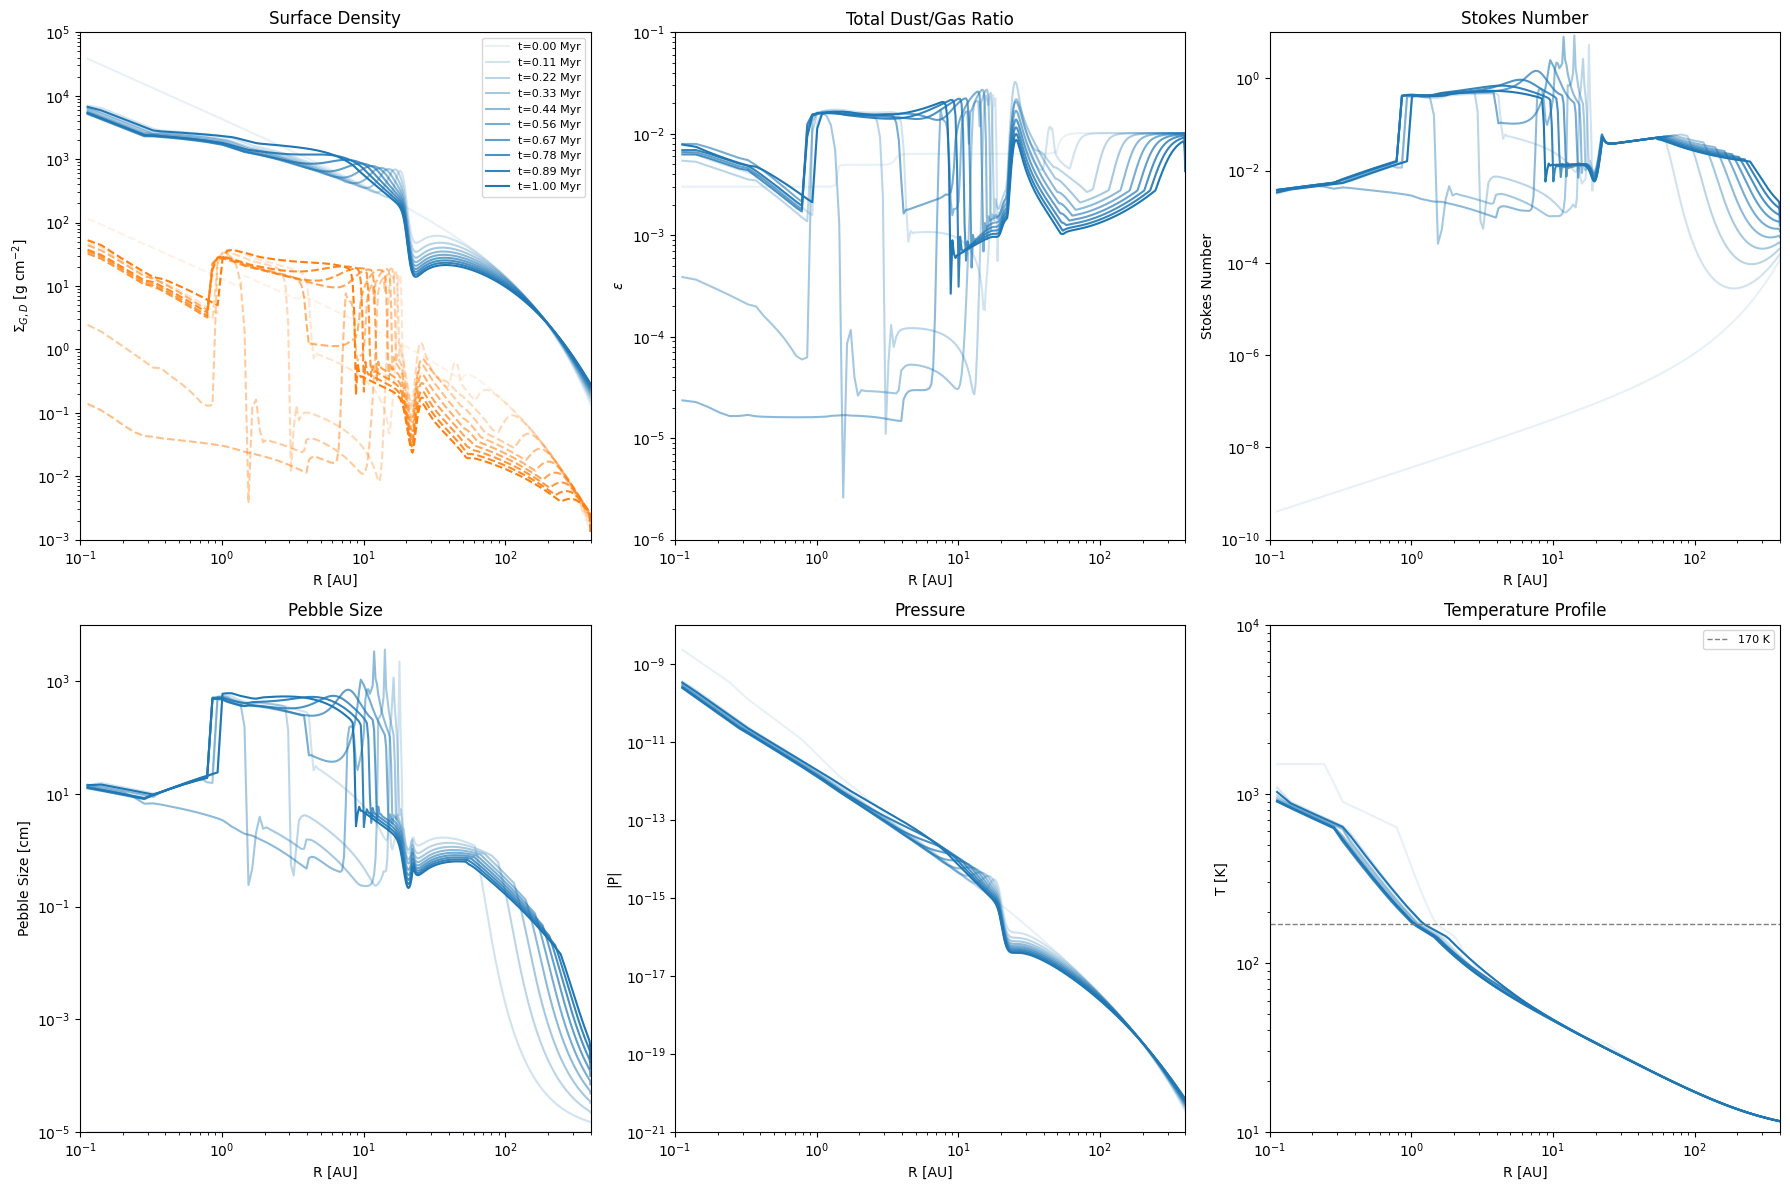

In [91]:
plot_disc_values()

# 13. Torque Maps

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/VaryingAlphaTesting/torque_maps.png


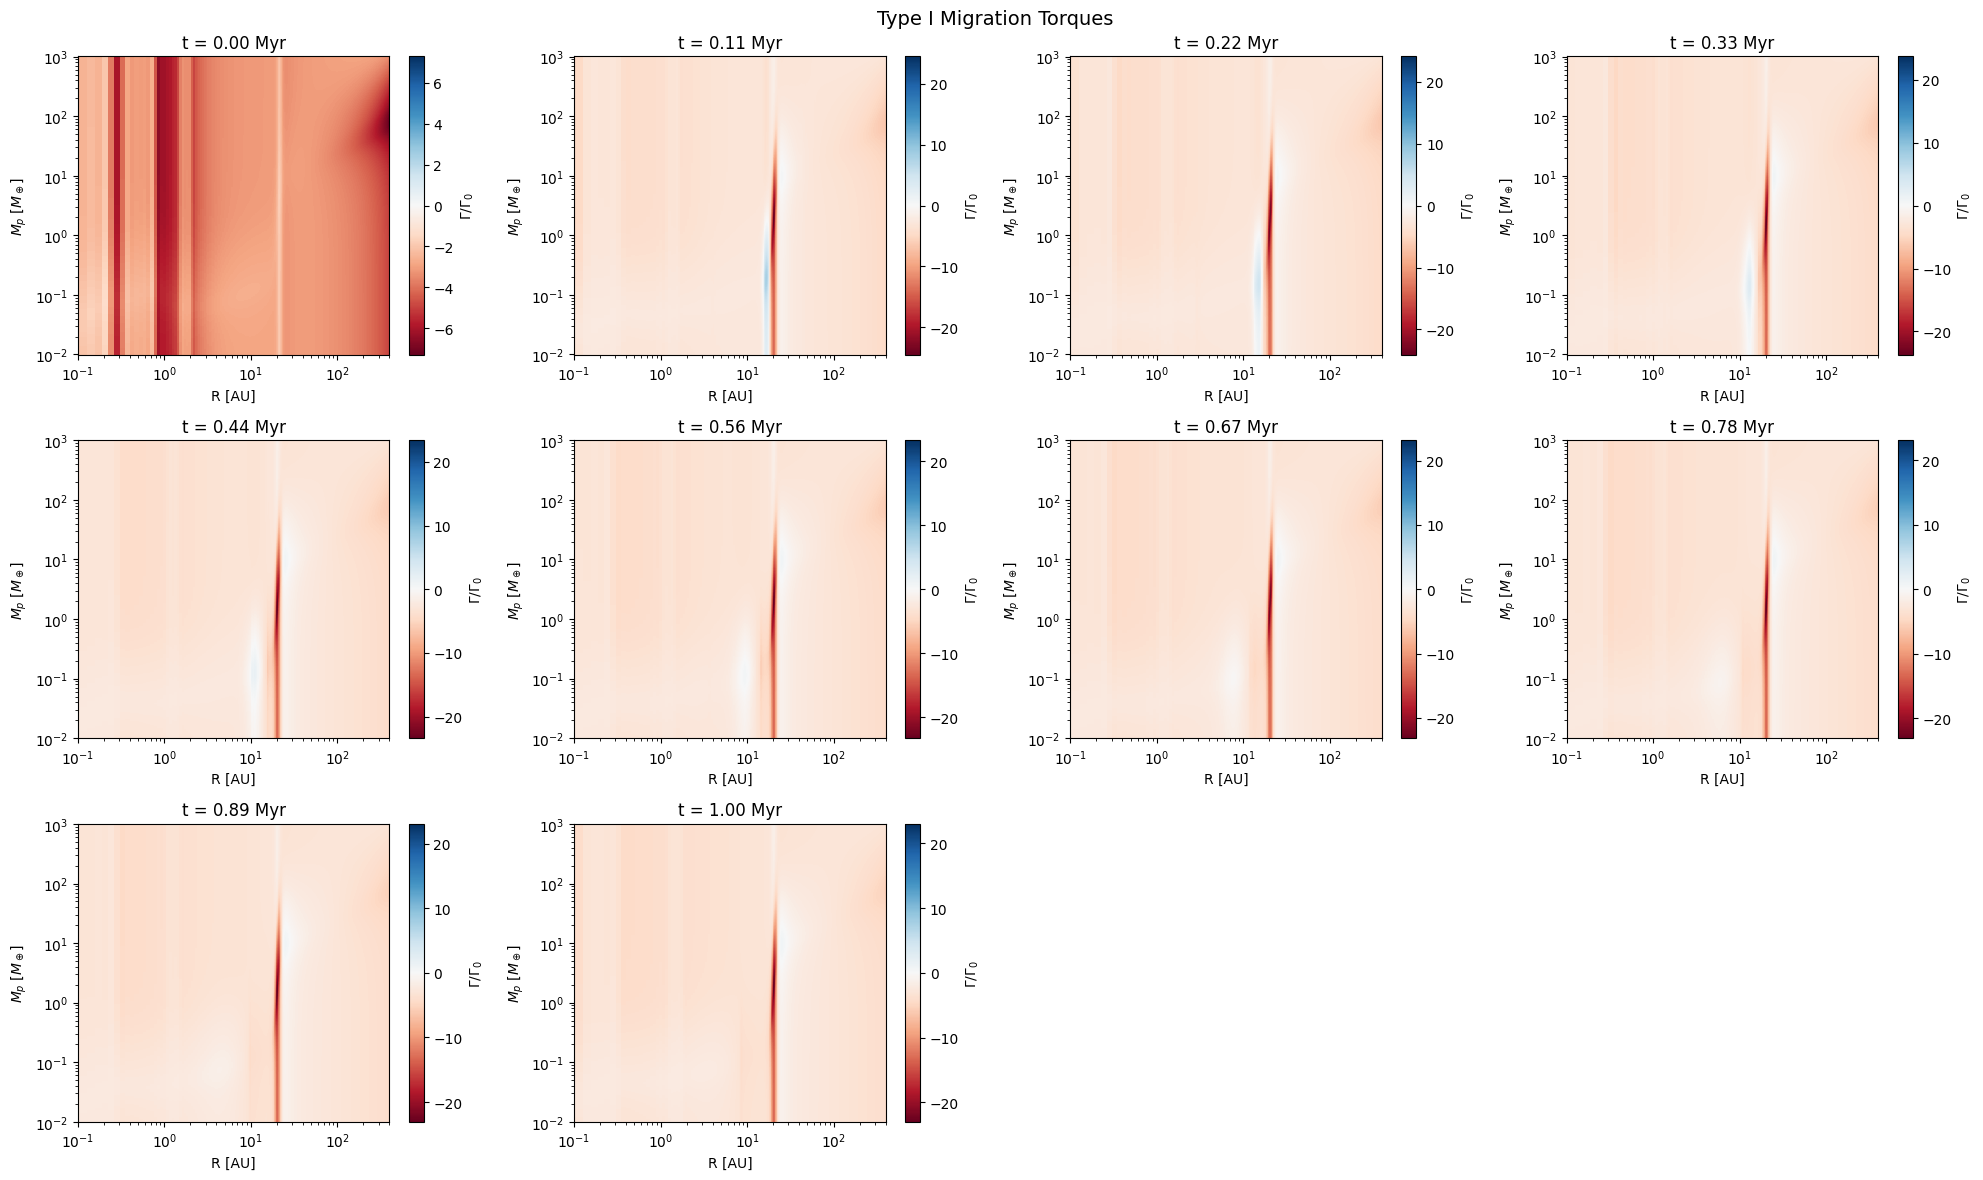

In [92]:

n_maps = len(torque_maps['maps'])
ncols = 4
nrows = int(np.ceil(n_maps / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = np.atleast_2d(axes)

for idx in range(n_maps):
    ax = axes[idx // ncols, idx % ncols]
    T_map = torque_maps['maps'][idx]
    t_label = torque_maps['t_yr'][idx]

    # Symmetric colour scale around zero
    vmax = np.max(np.abs(T_map))
    vmin = -vmax

    im = ax.pcolormesh(
        radius_array, mass_array, T_map,
        cmap='RdBu',        # red = inward (negative), blue = outward (positive)
        vmin=vmin, vmax=vmax,
        shading='auto'
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$M_p$ [$M_\oplus$]')
    ax.set_title(f't = {t_label/1e6:.2f} Myr')
    ax.set_xlim(R_in, R_out)
    fig.colorbar(im, ax=ax, label=r'$\Gamma / \Gamma_0$')

# Hide unused axes
for idx in range(n_maps, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

plt.suptitle('Type I Migration Torques', fontsize=14)
plt.tight_layout()
savefig('torque_maps.png', subfolder)
plt.show()


# 14. Accretion Rate Plot

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/VaryingAlphaTesting/Mdot_star.png


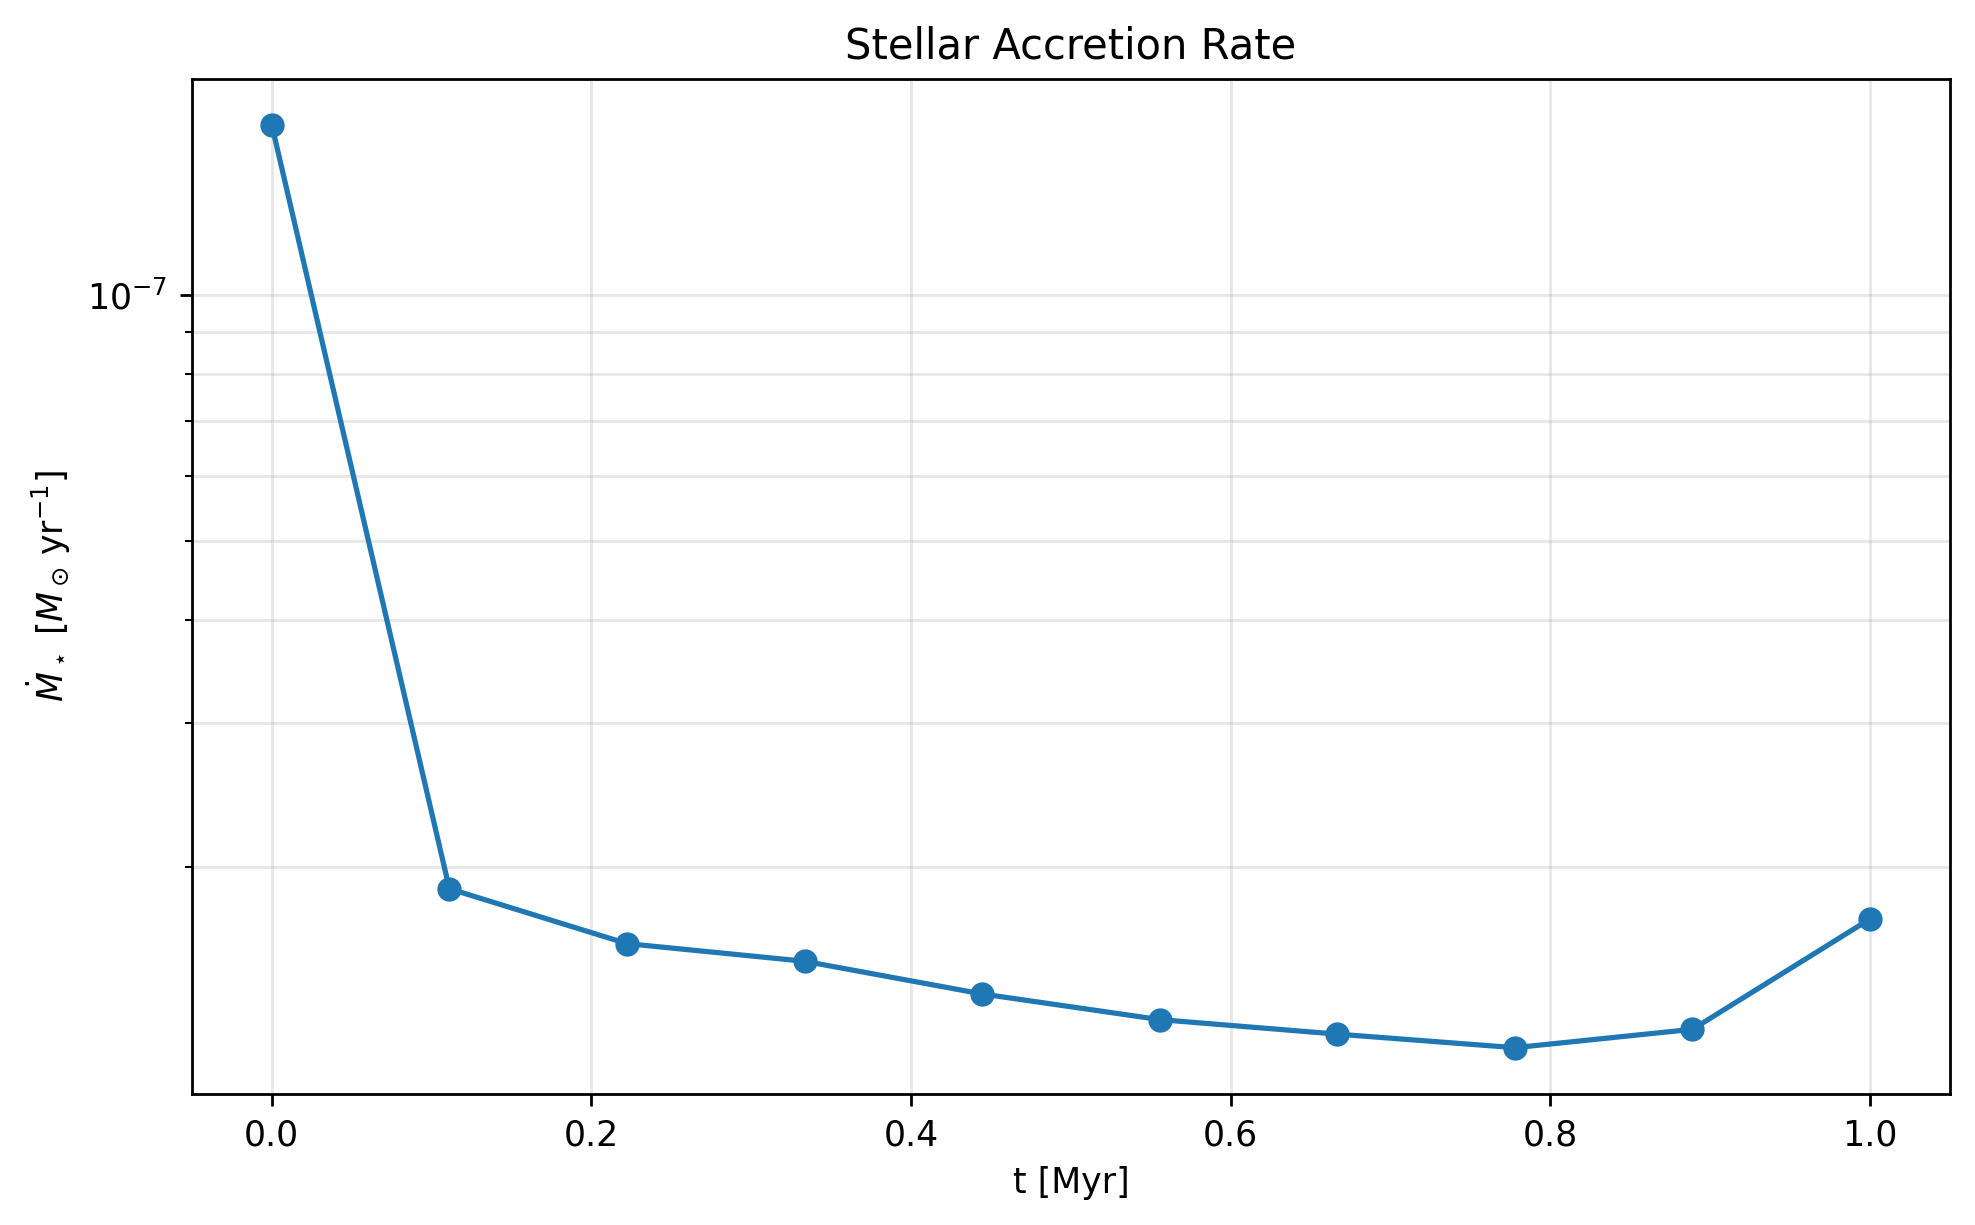

In [93]:
fig, ax = plt.subplots(figsize=(8, 5), dpi = 250)

ax.semilogy(np.array(history['t_yr']) / 1e6, np.array(history['Mdot_star']), 'o-', color='C0', lw=1.5)
ax.set_xlabel('t [Myr]')
ax.set_ylabel(r'$\dot{M}_\star$ [$M_\odot\,\mathrm{yr}^{-1}$]')
ax.set_title('Stellar Accretion Rate')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

savefig('Mdot_star.png', subfolder) 
plt.show()

In [94]:
history['Mdot_star']

[np.float64(1.6112186368859608e-07),
 np.float64(1.8810988423448478e-08),
 np.float64(1.6119214463323944e-08),
 np.float64(1.5339346378626583e-08),
 np.float64(1.3992300812257292e-08),
 np.float64(1.3018287503147141e-08),
 np.float64(1.2496841049716007e-08),
 np.float64(1.2030444894521443e-08),
 np.float64(1.266779933956153e-08),
 np.float64(1.7278552759572797e-08)]

/var/folders/gs/62b6262j1kx0f9d88dw3sf9c0000gn/T/ipykernel_79259/1506849515.py:15: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(10**(np.floor(np.log10(np.min(np.isfinite(history['Mdot_r']))))), 10**(np.ceil(np.log10(np.max(np.isfinite(history['Mdot_r']))))))


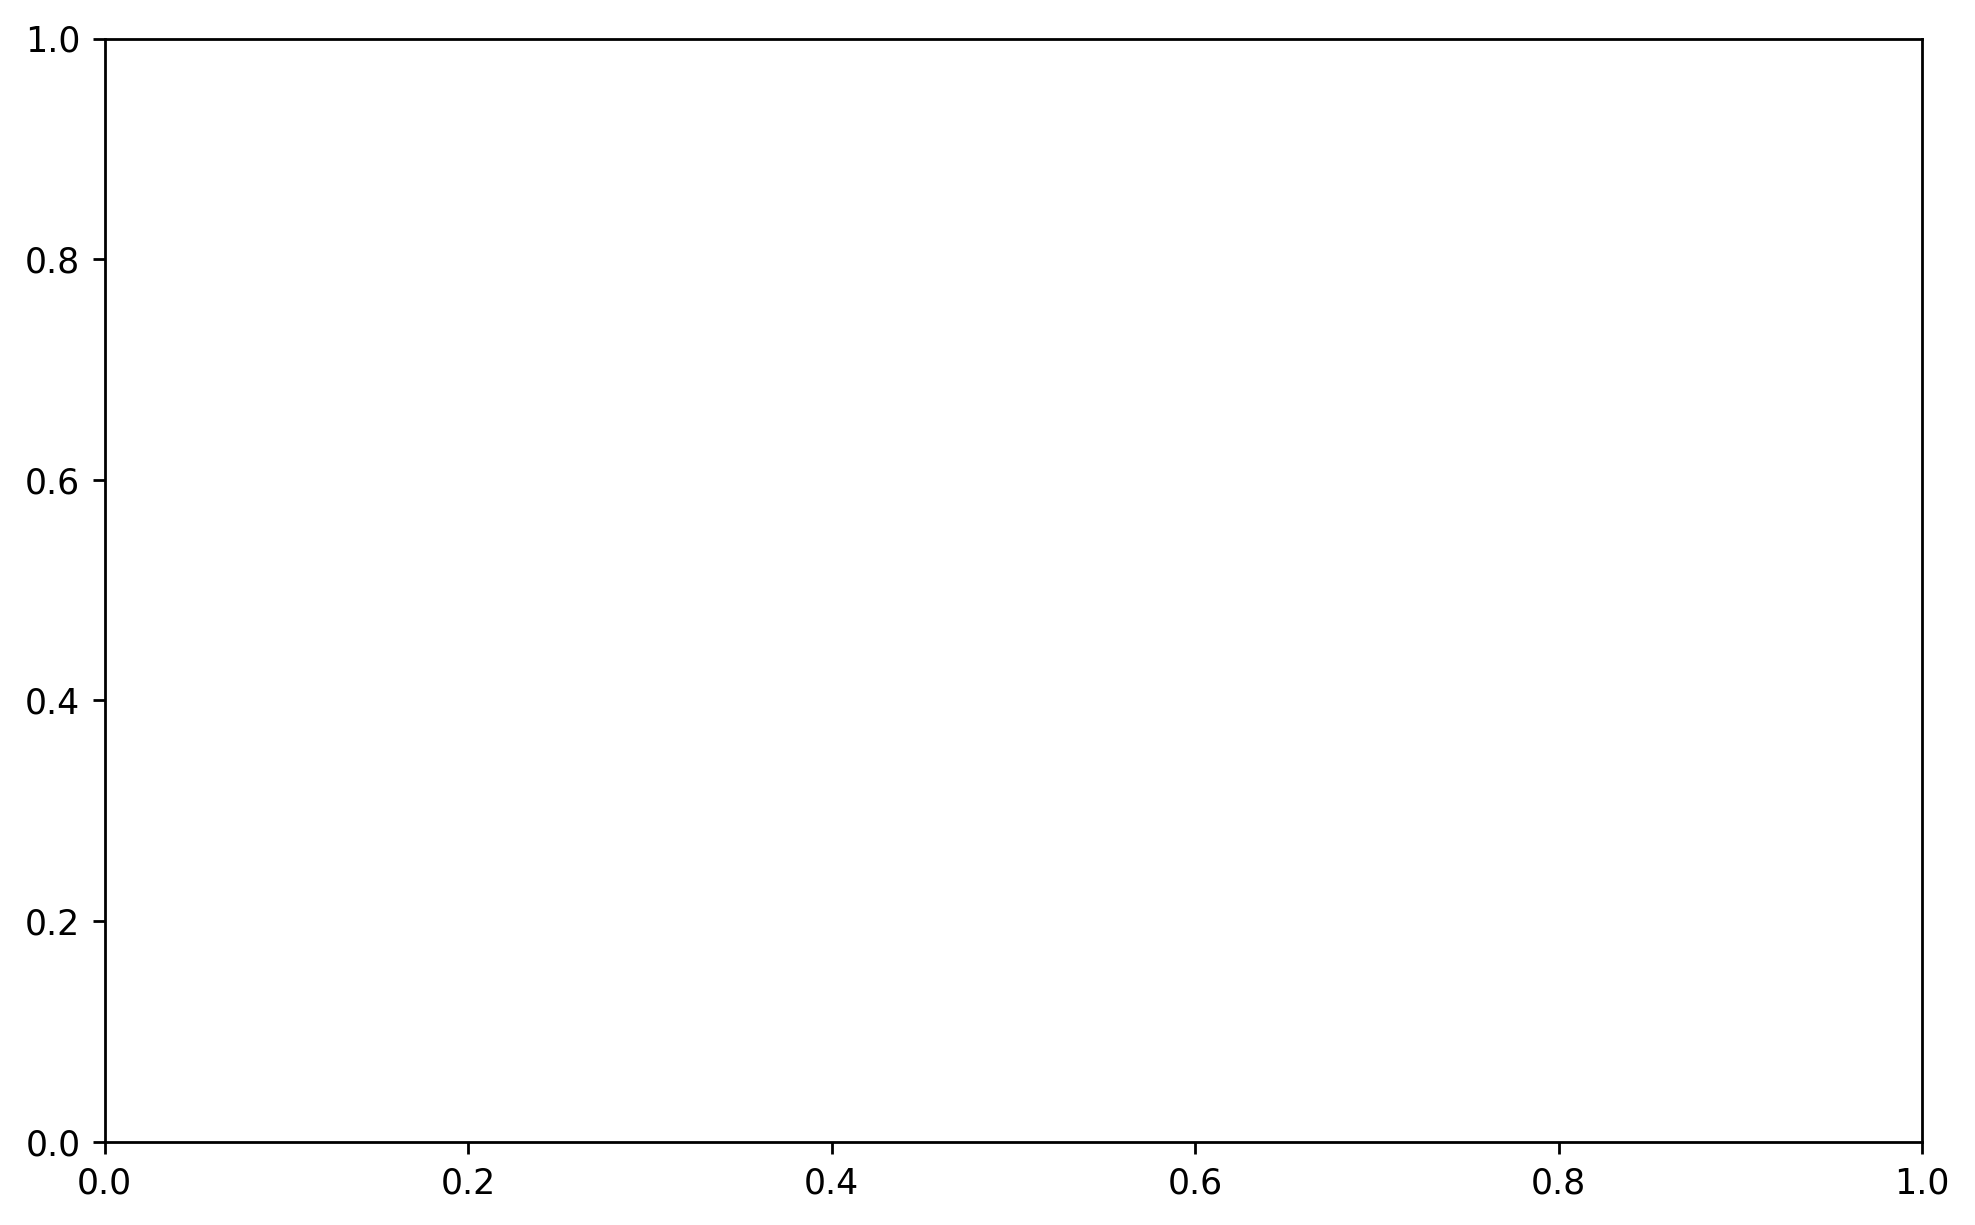

In [95]:
fig, ax = plt.subplots(figsize=(8, 5), dpi = 250)

n_snaps = len(history['t_yr'])
alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

ax = axes[1, 0]
for i, line in enumerate(history['Mdot_r']):
    ax.loglog(history['R_faces'][i], history['Mdot_r'][i], linestyle='solid', color='C0', alpha=alphas[i],
                label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=1.5)

ax.set_xlabel(r'$R_{\rm faces}$ [AU]')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot\,\mathrm{yr}^{-1}$]')
ax.set_title('Radial Accretion Rate')
ax.set_xlim(R_in, R_out)
ax.set_ylim(10**(np.floor(np.log10(np.min(np.isfinite(history['Mdot_r']))))), 10**(np.ceil(np.log10(np.max(np.isfinite(history['Mdot_r']))))))
ax.minorticks_on()
ax.tick_params(axis='y', which='minor', length=2)
plt.tight_layout()

#savefig('Mdot_r.png', subfolder)
plt.show()

In [ ]:
np.array(history['R_faces']).shape, np.array(history['Mdot_r']).shape

((499,), (10, 499))

In [ ]:
np.array(history['R_faces'])

array([[1.26448025e-01, 1.55995657e-01, 1.88642896e-01, ...,
        3.95289843e+02, 3.96856796e+02, 3.98426848e+02],
       [1.26448025e-01, 1.55995657e-01, 1.88642896e-01, ...,
        3.95289843e+02, 3.96856796e+02, 3.98426848e+02],
       [1.26448025e-01, 1.55995657e-01, 1.88642896e-01, ...,
        3.95289843e+02, 3.96856796e+02, 3.98426848e+02],
       ...,
       [1.26448025e-01, 1.55995657e-01, 1.88642896e-01, ...,
        3.95289843e+02, 3.96856796e+02, 3.98426848e+02],
       [1.26448025e-01, 1.55995657e-01, 1.88642896e-01, ...,
        3.95289843e+02, 3.96856796e+02, 3.98426848e+02],
       [1.26448025e-01, 1.55995657e-01, 1.88642896e-01, ...,
        3.95289843e+02, 3.96856796e+02, 3.98426848e+02]], shape=(10, 499))

In [ ]:
np.array(history['Mdot_r'])

array([[-6.67313293e-06, -5.12959924e-06, -4.04361977e-06, ...,
        -2.93192749e-09, -2.89586410e-09, -2.86011169e-09],
       [ 3.10139011e-08,  3.10176542e-08,  3.10161084e-08, ...,
        -2.93792793e-09, -2.89766535e-09, -2.85766248e-09],
       [ 2.49383363e-08,  2.49542050e-08,  2.49690720e-08, ...,
        -3.00706578e-09, -2.96738172e-09, -2.92799472e-09],
       ...,
       [ 1.95601134e-08,  1.95702789e-08,  1.95790412e-08, ...,
        -3.32497794e-09, -3.28743248e-09, -3.25028887e-09],
       [ 1.89827212e-08,  1.89926815e-08,  1.90013066e-08, ...,
        -3.37608247e-09, -3.33915670e-09, -3.30258577e-09],
       [ 1.84589002e-08,  1.84686626e-08,  1.84771334e-08, ...,
        -3.42477531e-09, -3.38855434e-09, -3.35256999e-09]],
      shape=(10, 499))